<div style="position: relative; background: linear-gradient(135deg, #24398A 0%, #1a2a66 100%); border-radius: 20px 20px 0px 0px; padding: 30px;  box-shadow: 0 8px 16px rgba(36, 57, 138, 0.3);">
  
  
  <div style="position: absolute; top: 20px; right: 20px; background: white; padding: 4px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">
    <img src="images/logo_unison.jpg" alt="UNISON" style="height: 160px;">
  </div>
  
  
  <div style="position: absolute; top: 20px; left: 20px; background: white; padding: 4px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">
    <img src="images/genetic_banner.jpg" alt="Curso" style="height: 160px;">
  </div>
   
  
  <div style="color: white; max-width: 60%; margin: 0 auto; text-align: center;">
    <h1 style="color: #EBA93B; margin: 0; font-size: 28px; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);">
      Metaheurísticas para Ciencia de Datos: <br>Teoría y Práctica
    </h1><br>
    <h3 style="margin: 15px 0 5px 0; font-size: 16px; opacity: 0.95;">Maestría en Ciencia de Datos</br></br>
    Ramón Soto C. / ramon.soto@unison.mx</h3>
  </div>
</div>

<div style="background: white; border: 3px solid #EBA93B; border-radius: 0px 0px 20px 20px; padding: 25px;">
  <div style="display: flex; align-items: center; margin-bottom: 15px;">
    <div style="background: #24398A; color: white; font-size: 24px; font-weight: bold; padding: 10px 20px; border-radius: 8px; margin-right: 20px;">02</div>
    <div>
      <h2 style="color: #24398A; margin: 0;">Sistemas complejos y la naturaleza de las series de tiempo</h2>
      <p style="color: #666; margin: 5px 0 0 0; font-style: italic;">Una mirada al mundo real, más allá de las funciones lisas y los modelos dóciles</p>
    </div>
  </div>
  
  <div style="background: #f8f9fa; padding: 15px; border-radius: 5px; border-left: 4px solid #24398A;">
    <h4><strong>Presentación general:</strong></h4>
    <p>La ciencia de datos tradicional asume mundos lineales y estacionarios. Pero ¿qué ocurre cuando los datos provienen de sistemas dinámicos no lineales, caóticos o con propiedades emergentes? 
        </p>
      <p >
        En dominios como los mercados financieros o la dinámica atmosférica, no existe una dinámica estable que permita modelar el sistema mediante la reducción a sus componentes individuales. Los <b>sistemas complejos</b> se caracterizan por la emergencia de patrones globales a partir de interacciones locales simples. Para el científico de datos, esto implica reconocer que la linealidad es una excepción y que el verdadero reto reside en capturar la auto-organización y la sensibilidad a condiciones iniciales que definen el comportamiento de los datos en entornos reales.
    </p>
  </div>
</div>


<div style="
  background: #fdf8e3;
  border-left: 6px solid #d39e00;
  padding: 20px 25px;
  margin: 30px 0;
  border-radius: 8px;
  font-style: italic;
  color: #5a4a00;
  box-shadow: 0 4px 8px rgba(0,0,0,0.05);
">
  <p style="margin: 0; font-size: 16px; line-height: 1.6;">
    “As far as the laws of mathematics refer to reality, they are not certain,
    and as far as they are certain, they do not refer to reality.”
  </p>
  <p style="margin: 10px 0 0 0; text-align: right; font-weight: bold;">
    — Albert Einstein
  </p>
</div>



In [1]:
# CONFIGURACIÓN INICIAL
# =====================

# Librerías numéricas y científicas básicas
import numpy as np
import pandas as pd
import math

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Series de tiempo y dinámica (se usarán progresivamente)
from scipy.integrate import odeint
import scipy.stats as stats

# Análisis no lineal y datos reales
import nolds
import yfinance as yf

from collections import deque

# ---------------------
# Configuración estética
# ---------------------
np.set_printoptions(precision=4, suppress=True)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Reproducibilidad
np.random.seed(42)

print("Entorno inicial listo.")


Entorno inicial listo.


## 1. Del lenguaje combinatorio al dominio temporal

Los problemas de optimización son un **lenguaje formal** para expresar la búsqueda de soluciones en espacios complejos. Las metaheurísticas surgieron como respuesta a problemas combinatorios NP-duros (TSP, scheduling, knapsack), donde la enumeración exhaustiva es computacionalmente intratable.

Pero su utilidad trasciende lo combinatorio.

Cualquier problema que pueda expresarse como:

$$\text{Encontrar } \theta^* = \arg\min_{\theta \in \Theta} f(\theta)$$

donde $f(\theta)$ sea **costosa de evaluar**, tenga **múltiples óptimos locales** o carezca de **estructura diferenciable**, es candidato natural para metaheurísticas.

Y eso incluye un dominio fundamental en ciencia de datos: **las series de tiempo**.

### Series de tiempo: más allá de la predicción estadística

Tradicionalmente, las series de tiempo se abordan mediante modelos paramétricos (como ARIMA o GARCH) o, más recientemente, mediante arquitecturas de aprendizaje profundo (principalmente LSTM, Transformers). Estos enfoques asumen que:

- Existe una forma funcional razonable (lineal, log-lineal, recurrente)
- Los parámetros pueden estimarse por máxima verosimilitud y descenso de gradiente
- Se mantienen propiedades estadísticas como estacionariedad y ergodicidad

Pero cuando trabajamos con **series complejas**—generadas por sistemas caóticos, multiescala o con cambios de régimen—estos supuestos fallan:

| **Aspecto** | **Enfoque Clásico** | **Realidad en Series Complejas** |
|-------------|---------------------|----------------------------------|
| **Forma funcional** | Conocida (AR, MA) | Desconocida, posiblemente no paramétrica |
| **Parámetros** | Pocos, estimables por MLE | Muchos, interdependientes, multimodales |
| **Horizonte de predicción** | Asintóticamente estable | Limitado por exponente de Lyapunov |
| **Estacionariedad** | Asumida o transformable | Violada estructuralmente (bifurcaciones) |
| **Optimización** | Convexa (o casi) | No convexa, discontinua, ruidosa |

En estos escenarios, las metaheurísticas no son una alternativa—son **la herramienta natural**.

## 2. La complejidad como condición natural del mundo

Cuando hablamos de ciencia de datos, solemos imaginar modelos aplicados a conjuntos ordenados de información, donde los fenómenos siguen patrones discernibles, regularidades estables y estructuras razonablemente predecibles. Pero el mundo real rara vez se comporta así.

Gran parte de los fenómenos que estudiamos en economía, biología, física, energía, clima, neurología y sistemas sociales **no son lineales ni estacionarios**. Son sistemas donde millones de microsucesos interactúan constantemente, dando lugar a comportamientos globales que no pueden deducirse de sus partes.

A esa familia de fenómenos la llamamos **sistemas complejos**.

Y una de sus huellas más frecuentes son las **series de tiempo complejas**.

<br>
<p align="center">
  <img src="images/chaos.gif" width="600">
</p>


---

## 2. Fundamentos teóricos

### ¿Qué es un sistema complejo?

Un sistema complejo no es simplemente un sistema "complicado". Es un sistema donde:

* **Múltiples componentes interactúan localmente** (sin coordinador central)
* **Pequeñas variaciones dan lugar a grandes efectos** (sensibilidad a condiciones iniciales - **efecto mariposa**)
* **Estructuras globales emergen** sin diseño explícito (**emergencia**)
* **Comportamiento multimodal** (estable o caótico según contexto)
* **El ruido puede ser funcional**, no error de medición
* **Los modelos clásicos fallan** (lineales, gaussianos, estacionarios)

| Aspecto | Sistema Complicado | Sistema Complejo |
| :--- | :--- | :--- |
| Ejemplo | Motor de avión | Ecosistema, cerebro |
| Componentes | Muchos, pero independientes | Muchos, altamente acoplados e interdependientes |
| Comportamiento | Predecible dadas las partes | Emergente, no deducible |
| Análisis | Reduccionismo funciona | Reduccionismo falla |
| Causalidad | Lineal, trazable | No lineal, circular |
| Ruido | Error de medición | Parte funcional del sistema |
| Modelado | Ingeniería clásica | Teoría de sistemas dinámicos |

**Ejemplos Paradigmáticos**

* **Sistemas Físicos:** Clima global, Turbulencia en fluidos, Redes eléctricas
* **Sistemas Biológicos:** El cerebro (86 mil millones de neuronas), El corazón (arritmias), Redes de regulación genética
* **Sistemas Socio-Económicos:** Mercados financieros, Tráfico vehicular urbano, Pandemias (COVID-19)

**Característica común:** Son impredecibles en detalle, pero predecibles en estructura (atractores, patrones estadísticos).

### Propiedades emergentes: El todo es más que la suma

Una propiedad **emergente** es un comportamiento del sistema completo que no existe en ningún componente individual. 1 neurona tan sólo dispara o no dispara (~0/1); 86 mil millones de neuronas interactuando dan origen a la memoria, el lenguaje, la creatividad. **La complejidad no escala linealmente**




### Ejemplo simple: El Juego de la Vida de Conway

El **Juego de la Vida** (Conway's Game of Life) es un autómata celular inventado por el matemático John Conway en 1970. A pesar de su nombre, no es un "juego" en el sentido tradicional: no hay jugadores, no hay ganadores, no hay objetivos. Es un **universo artificial** que evoluciona según reglas matemáticas extremadamente simples.

<br>
<p align="center">
  <img src="images/3d-game-of-life.png" width="300">
</p>

### Universo: Una cuadrícula infinita

- Imaginemos una cuadrícula bidimensional infinita (como un tablero de ajedrez sin fin)
- Cada celda puede estar en uno de dos estados: **viva** (■) o **muerta** (□)
- El tiempo avanza en pasos discretos llamados **generaciones**
- En cada generación, TODAS las celdas se actualizan simultáneamente según sus vecinos

### Reglas: Asombrosamente simples

Cada celda tiene **8 vecinos** (arriba, abajo, izquierda, derecha y las 4 diagonales). El destino de cada celda depende únicamente de cuántos vecinos vivos tiene:

1. **Una célula viva con 2-3 vecinos → sobrevive**
- **Supervivencia:** Si tiene 2 o 3 vecinos vivos → sobrevive
- **Muerte por soledad:** Si tiene 0 o 1 vecinos → muere
- **Muerte por sobrepoblación:** Si tiene 4+ vecinos → muere

2. **Una célula muerta con 3 vecinos vivos → nace**
- **Nacimiento:** Si tiene exactamente 3 vecinos vivos → nace (revive)
- **Permanece muerta:** En cualquier otro caso

No hay aleatoriedad, no hay excepciones, no hay casos especiales. El comportamiento futuro del sistema está **completamente determinado** por su configuración inicial.


Inicializando con configuración ALEATORIA (30% células vivas)...



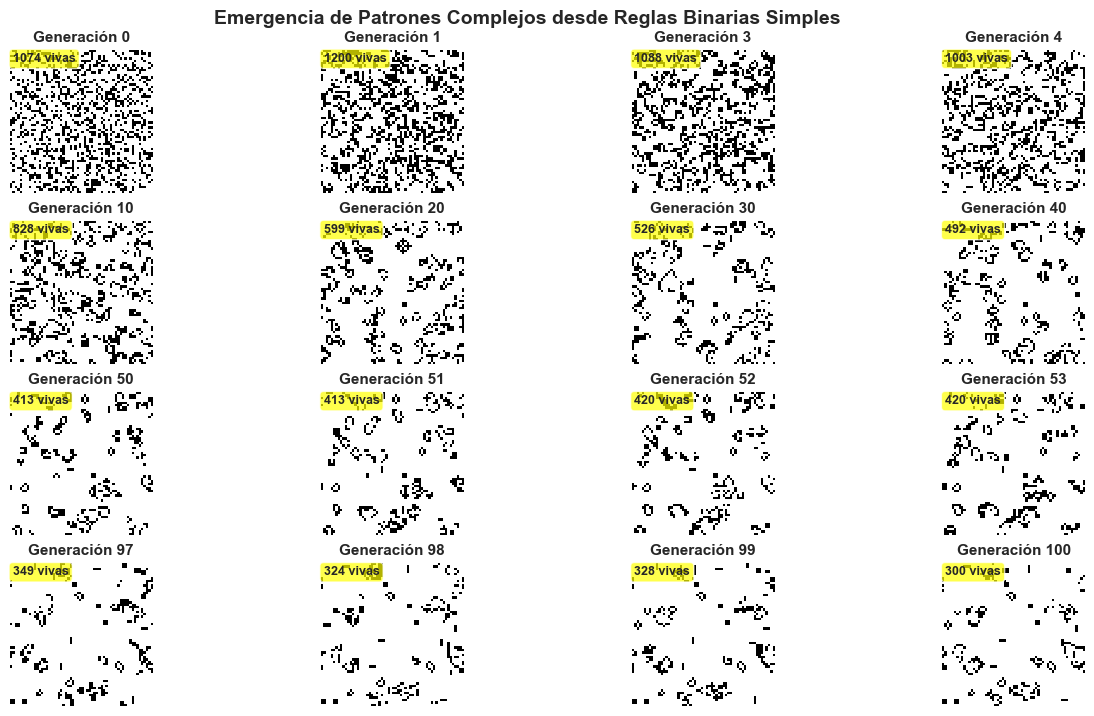

In [2]:
# Juego de la Vida de Conway - Emergencia más simple

from matplotlib.colors import ListedColormap

class GameOfLife:
    
    def __init__(self, size=50):
        self.size = size
        # Inicializar grid aleatorio
        self.grid = np.random.choice([0, 1], size=(size, size), p=[0.7, 0.3])
    
    def count_neighbors(self):
        """Contar vecinos vivos de cada célula (8 vecinos)"""
        neighbors = np.zeros_like(self.grid)
        for i in range(-1, 2):
            for j in range(-1, 2):
                if i == 0 and j == 0:
                    continue
                neighbors += np.roll(np.roll(self.grid, i, axis=0), j, axis=1)
        return neighbors
    
    def step(self):
        """Un paso de evolución: aplicar las 2 reglas simples"""
        neighbors = self.count_neighbors()
        
        # Regla 1: Supervivencia (2-3 vecinos)
        survive = (self.grid == 1) & ((neighbors == 2) | (neighbors == 3))
        
        # Regla 2: Nacimiento (exactamente 3 vecinos)
        birth = (self.grid == 0) & (neighbors == 3)
        
        # Nuevo estado
        self.grid = (survive | birth).astype(int)


# Crear simulación
print("Inicializando con configuración ALEATORIA (30% células vivas)...\n")
game = GameOfLife(size=60)

# Visualizar evolución
fig, axes = plt.subplots(4, 4, figsize=(16, 8))
axes = axes.flatten()

cmap = ListedColormap(['white', 'black'])
times = [0, 1, 3, 4, 10, 20, 30, 40, 50, 51, 52, 53, 97, 98, 99, 100]      # Generaciónes a desplegar

for idx, t in enumerate(times):
    # Avanzar simulación
    if idx > 0:
        steps = times[idx] - times[idx-1]
        for _ in range(steps):
            game.step()
    
    # Graficar
    axes[idx].imshow(game.grid, cmap=cmap, interpolation='nearest')
    axes[idx].set_title(f'Generación {t}', fontweight='bold', fontsize=11)
    axes[idx].axis('off')
    
    # Anotar número de células vivas
    n_alive = game.grid.sum()
    axes[idx].text(0.02, 0.98, f'{n_alive} vivas', 
                   transform=axes[idx].transAxes,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
                   fontsize=9, fontweight='bold')

plt.suptitle('Emergencia de Patrones Complejos desde Reglas Binarias Simples', 
             fontsize=14, fontweight='bold')
plt.subplots_adjust(wspace=0.01, hspace=0.2, top=0.93) 
plt.show()


#### Conclusiones del Juego de la Vida: Lecciones para sistemas complejos

Partimos de una **configuración completamente aleatoria** (30% de células vivas) y aplicamos **solo 2 reglas deterministas**. El resultado es el siguiente:

* **Gen 0-4:** Caos inicial se reorganiza localmente
* **Gen 10-40:** Emergen estructuras estables (
* **Gen 50+:** El sistema alcanza un estado cuasi-estable con osciladores periódicos
* **Gen 100:** Patrón complejo auto-organizado que nunca fue "diseñado"

---

### Características de sistemas complejos presentes

| Característica | Manifestación en el Juego de la Vida |
|:--------------|:------------------------------------|
| **Interacciones locales** | Cada célula solo "conoce" a sus 8 vecinos |
| **Emergencia** | Patrones globales que ninguna célula individual contiene |
| **Auto-organización** | Orden emerge del caos sin control central |
| **Determinismo caótico** | Reglas simples → comportamiento impredecible en detalle |
| **Sensibilidad a condiciones iniciales** | Cambiar 1 célula inicial puede alterar completamente la evolución |


## 3. La firma matemática: Caos, atractores y sensibilidad

Los sistemas complejos suelen presentar **caos determinista**.

**Caos determinista NO significa:**
- Comportamiento aleatorio
- Falta de ecuaciones
- Impredecibilidad absoluta

**Caos determinista SÍ significa:**
- Dinámicas gobernadas por **ecuaciones exactas y deterministas**
- Que producen comportamientos **aparentemente aleatorios**
- **Sensibilidad extrema** a condiciones iniciales (efecto mariposa)
- **Predecibles a corto plazo**, impredecibles a largo plazo


### El atractor extraño de Lorenz: El icono del caos

Edward Lorenz (1963) descubrió el caos determinista al simplificar las ecuaciones de convección atmosférica. Buscaba predecir el clima y encontró que era fundamentalmente impredecible a largo plazo.

**Sistema de ecuaciones diferenciales:**

$$
\begin{aligned}
\frac{dx}{dt} &= \sigma(y - x) \quad &&\text{(transferencia de calor)} \\
\frac{dy}{dt} &= x(\rho - z) - y \quad &&\text{(diferencia de temperatura horizontal)} \\
\frac{dz}{dt} &= xy - \beta z \quad &&\text{(diferencia de temperatura vertical)}
\end{aligned}
$$

**Parámetros típicos:** $\sigma = 10$ (número de Prandtl), $\rho = 28$ (número de Rayleigh), $\beta = 8/3$ (aspecto geométrico)

**Variables:**
- $x$: tasa de rotación del fluido
- $y$: diferencia de temperatura entre corrientes ascendentes y descendentes
- $z$: desviación del perfil de temperatura lineal

---

### Propiedades del atractor de Lorenz

| Propiedad | Descripción | Implicación |
|:----------|:------------|:------------|
| **Sensibilidad a condiciones iniciales** | Dos trayectorias inicialmente cercanas divergen exponencialmente | Error inicial de 0.000001 → impredecibilidad en ~20 pasos |
| **Atractor extraño** | Forma de "mariposa" en 3D con estructura fractal | Dimensión no entera (~2.06, entre superficie y volumen) |
| **No periódico** | La trayectoria nunca se repite exactamente | No hay ciclos, pero sí patrones estadísticos |
| **Determinista** | Mismas condiciones iniciales → misma trayectoria | Completamente reproducible, nada aleatorio |
| **Disipativo** | El volumen en el espacio de fase se contrae | Todas las trayectorias convergen al atractor |
| **Topológicamente mezclador** | Regiones cercanas se separan y distantes se juntan | Mezcla eficiente, como batir un líquido |


In [3]:
import matplotlib.cm as cm

# ============================================================================
# 0. CONFIGURACIÓN INICIAL - PARÁMETROS Y SISTEMA
# ============================================================================
def lorenz_system(state, t, sigma, rho, beta):
    """
    Sistema de Lorenz: modelo simplificado de convección atmosférica
    que exhibe comportamiento caótico.
    """
    x, y, z = state              # Desempaquetar el estado en las tres variables
    dxdt = sigma * (y - x)       # Tasa de cambio en x (la derivada)
    dydt = x * (rho - z) - y     # Tasa de cambio en y
    dzdt = x * y - beta * z      # Tasa de cambio en z
    return [dxdt, dydt, dzdt]

# Parámetros clásicos para régimen caótico (valores históricos de Lorenz, 1963)
sigma = 10.0      # Número de Prandtl (relación entre viscosidad y difusividad térmica)
rho = 28.0        # Número de Rayleigh (controla la inestabilidad convectiva)
beta = 8.0 / 3.0  # Parámetro geométrico relacionado con la relación de aspecto

# Condiciones iniciales - ¡DEMOSTRACIÓN DEL EFECTO MARIPOSA!
# Dos estados iniciales casi idénticos divergen exponencialmente en sistemas caóticos
initial_state_1 = [0.0, 1.0, 1.05]
initial_state_2 = [0.0, 1.0, 1.05 + 1e-3]  # Perturbación infinitesimal en z

# Tiempo de simulación: vector de 10000 puntos equiespaciados entre 0 y 40 unidades de tiempo
t = np.linspace(0, 40, 10000)  # Genera un arreglo de tiempos para la integración

# Variables para mostrar información (solo para visualización en el print)
x1, y1, z1 = initial_state_1
x2, y2, z2 = initial_state_2

print("SISTEMA DE LORENZ")
print(f"Parámetros del caos: σ={sigma}, ρ={rho}, β={beta:.4f}")
print(f"\nCondición inicial 1: [x={x1}, y={y1}, z={z1}]")
print(f"Condición inicial 2: [x={x2}, y={y2}, z={z2}]")
print(f"Diferencia inicial: Δz = {z2 - z1:.2e} (perturbación mínima)")
print("="*70)

# Integración numérica de las ecuaciones diferenciales
# odeint resuelve sistemas de EDOs usando métodos numéricos (por defecto: Adams/BDF)
trajectory_1 = odeint(lorenz_system, initial_state_1, t, args=(sigma, rho, beta))
trajectory_2 = odeint(lorenz_system, initial_state_2, t, args=(sigma, rho, beta))


SISTEMA DE LORENZ
Parámetros del caos: σ=10.0, ρ=28.0, β=2.6667

Condición inicial 1: [x=0.0, y=1.0, z=1.05]
Condición inicial 2: [x=0.0, y=1.0, z=1.051]
Diferencia inicial: Δz = 1.00e-03 (perturbación mínima)


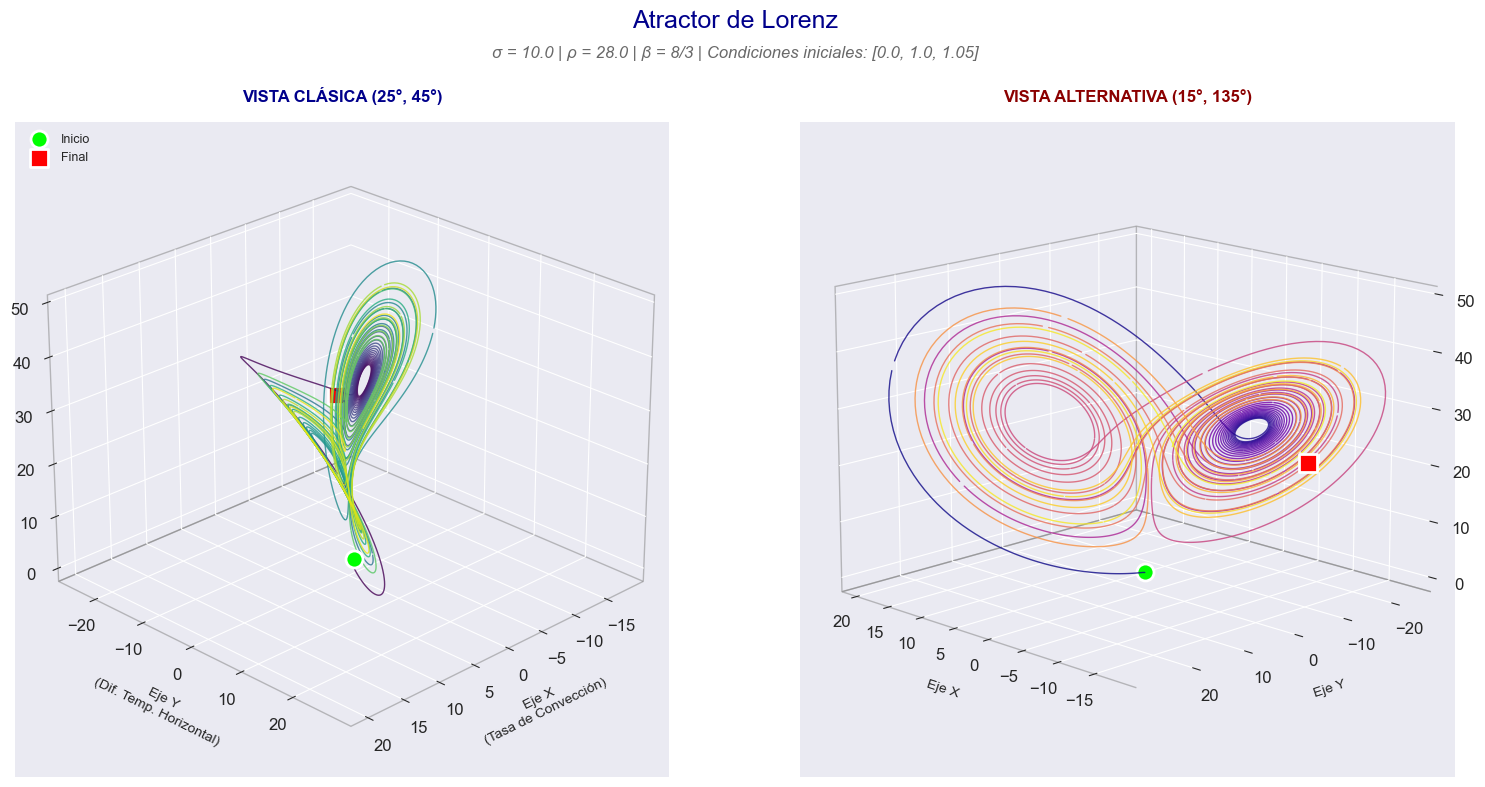

In [4]:
# ============================================================================
# 1. FIGURA PRINCIPAL: DOS VISTAS 3D DEL ATRACTOR
# ============================================================================

# Estilo visual: uso de seaborn-darkgrid para mejor contraste
plt.style.use('seaborn-v0_8-darkgrid')

fig = plt.figure(figsize=(16, 8))

# TÍTULO COMÚN PARA AMBAS GRÁFICAS
fig.suptitle('Atractor de Lorenz', fontsize=18, color='darkblue', y=1.05)

# Subtítulo con parámetros específicos (position 0.5, 0.99 relativo a la figura)
fig.text(0.5, 0.99, 
         'σ = 10.0 | ρ = 28.0 | β = 8/3 | Condiciones iniciales: [0.0, 1.0, 1.05]', 
         ha='center', fontsize=12, color='dimgray', style='italic')

# Paleta de colores para evolución temporal: cm.viridis crea gradiente continuo
# np.linspace genera 10000 valores entre 0 y 1 para mapear al colormap
colors = cm.viridis(np.linspace(0, 1, len(trajectory_1)))

# 1.1. VISTA 3D PRINCIPAL - ÁNGULO CLÁSICO
# Crear primer subplot en grid 1x2, posición 1, con proyección 3D
ax1 = fig.add_subplot(121, projection='3d')

# Dibujar trayectoria segmentada para gradiente de color temporal
# Se divide en segmentos de 100 puntos para aplicar colores diferentes
# El color representa el tiempo (inicio: azul oscuro, fin: amarillo)
for i in range(0, len(trajectory_1)-100, 100):
    ax1.plot(trajectory_1[i:i+100, 0],  # Coordenadas X del segmento
             trajectory_1[i:i+100, 1],  # Coordenadas Y del segmento
             trajectory_1[i:i+100, 2],  # Coordenadas Z del segmento
             color=colors[i], alpha=0.8, lw=1.0)  # Transparencia y grosor

# Marcar punto inicial con marcador circular verde
ax1.scatter(*initial_state_1, color='lime', s=150, marker='o', 
           edgecolor='white', linewidth=2, label='Inicio', zorder=10)
           # zorder=10 asegura que los puntos queden sobre la trayectoria

# Marcar punto final con marcador cuadrado rojo
ax1.scatter(*trajectory_1[-1], color='red', s=150, marker='s', 
           edgecolor='white', linewidth=2, label='Final', zorder=10)

# Configurar título y etiquetas de ejes con información física
ax1.set_title("VISTA CLÁSICA (25°, 45°)", fontweight='bold', fontsize=12, 
              color='darkblue', pad=15)  # pad añade espacio sobre el título
ax1.set_xlabel("Eje X\n(Tasa de Convección)", fontsize=10, labelpad=10)
ax1.set_ylabel("Eje Y\n(Dif. Temp. Horizontal)", fontsize=10, labelpad=10)
ax1.set_zlabel("Eje Z\n(Dif. Temp. Vertical)", fontsize=10, labelpad=10)

# Configuración visual para mejor claridad
ax1.grid(True, alpha=0.3)  # Cuadrícula semitransparente
# Hacer paneles de ejes transparentes para no obstruir vista
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False
# Bordes de paneles en gris para referencia espacial
ax1.xaxis.pane.set_edgecolor('gray')
ax1.yaxis.pane.set_edgecolor('gray')
ax1.zaxis.pane.set_edgecolor('gray')

# Configurar ángulo de vista: elevación 25°, azimut 45° (vista estándar)
ax1.view_init(elev=25, azim=45)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)  # Leyenda con fondo semitransparente

# 1.2. VISTA 3D ALTERNATIVA - PERSPECTIVA DIFERENTE
ax2 = fig.add_subplot(122, projection='3d')  # Segundo subplot, posición 2

# Colormap alternativo para variedad visual
colors2 = cm.plasma(np.linspace(0, 1, len(trajectory_1)))

# Dibujar misma trayectoria con diferente esquema de color
for i in range(0, len(trajectory_1)-100, 100):
    ax2.plot(trajectory_1[i:i+100, 0], 
             trajectory_1[i:i+100, 1], 
             trajectory_1[i:i+100, 2],
             color=colors2[i], alpha=0.8, lw=1.0)

# Puntos de inicio y fin (sin leyenda para evitar sobrecarga)
ax2.scatter(*initial_state_1, color='lime', s=150, marker='o', 
           edgecolor='white', linewidth=2, zorder=10)
ax2.scatter(*trajectory_1[-1], color='red', s=150, marker='s', 
           edgecolor='white', linewidth=2, zorder=10)

# Configurar segunda vista
ax2.set_title("VISTA ALTERNATIVA (15°, 135°)", fontweight='bold', 
              fontsize=12, color='darkred', pad=15)
ax2.set_xlabel("Eje X", fontsize=10, labelpad=10)
ax2.set_ylabel("Eje Y", fontsize=10, labelpad=10)
ax2.set_zlabel("Eje Z", fontsize=10, labelpad=10)

# Configuración visual idéntica a primera vista
ax2.grid(True, alpha=0.3)
ax2.xaxis.pane.fill = False
ax2.yaxis.pane.fill = False
ax2.zaxis.pane.fill = False
ax2.xaxis.pane.set_edgecolor('gray')
ax2.yaxis.pane.set_edgecolor('gray')
ax2.zaxis.pane.set_edgecolor('gray')

# Ángulo de vista diferente para apreciar otras dimensiones
ax2.view_init(elev=15, azim=135)

# Ajuste fino del layout: márgenes y espacio entre subplots
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95, 
                    wspace=0.2, hspace=0.2)

plt.show()

En estas gráficas podemos observar la estructura en forma de "mariposa" o "máscara" que emerge espontáneamente a partir de ecuaciones deterministas simples en el sistema de Lorenz. El sistema orbita alternativamente alrededor de dos puntos fijos (centros de las "alas"), creando un patrón que nunca se repite exactamente. A pesar del comportamiento impredecible, la trayectoria permanece confinada a una región específica del espacio.

El gradiente de color (azul→amarillo en izquierda, púrpura→amarillo en derecha) representa el tiempo transcurrido desde t=0 hasta t=40.

La *vista clásica (25°, 45°)*, enfatiza la simetría bilateral y la estructura característica que dio nombre al "efecto mariposa". La *vista alternativa (15°, 135°)*, revela la complejidad tridimensional y cómo la trayectoria se entrelaza consigo misma en el espacio.


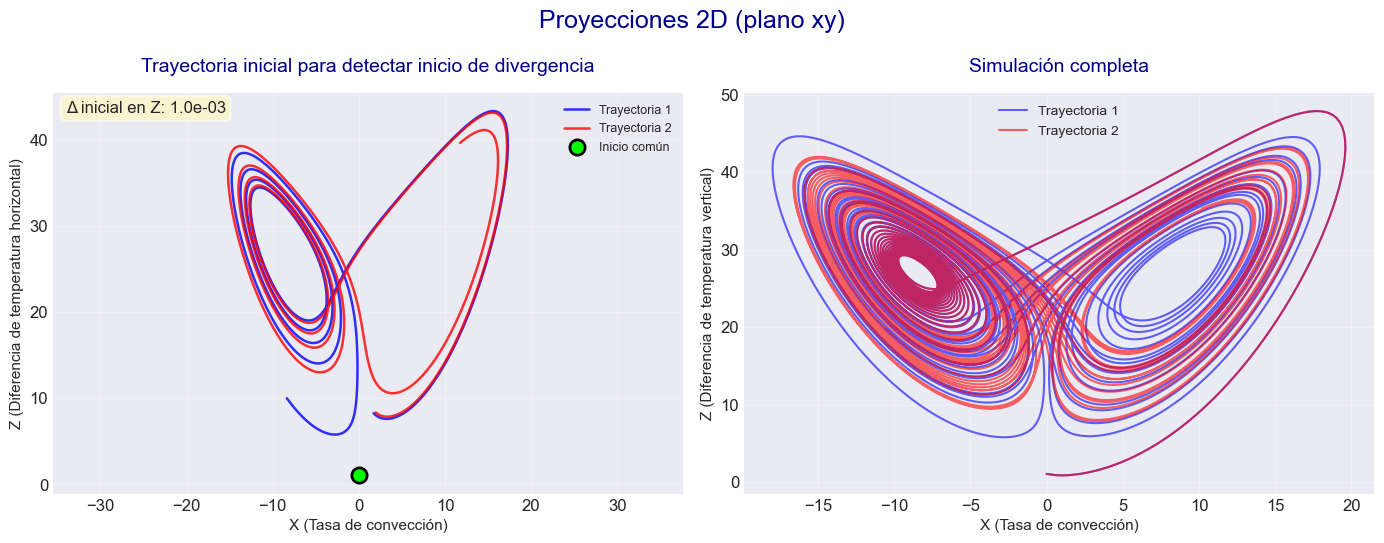

In [5]:
# ============================================================================
# 2. PROYECCIONES 2D: VISUALIZANDO EL EFECTO MARIPOSA
# ============================================================================

# Crear una nueva figura para las proyecciones 2D con 2 subgráficas horizontales
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Título común para las 2 proyecciones
fig3.suptitle('Proyecciones 2D (plano xy)', fontsize=18, color='darkblue', 
              y=0.982)   # título cerca del borde superior

# Calcular distancia euclidiana entre trayectorias a lo largo del tiempo
# Esta métrica cuantifica la divergencia de las trayectorias
distance = np.sqrt(np.sum((trajectory_1 - trajectory_2)**2, axis=1))

# Encontrar índices donde la distancia supera el umbral
threshold = 0.5          # Umbral arbitrario para considerar "divergencia significativa"
cross_idx = np.where(distance > threshold)[0]

# Tiempo en que ocurre la primera divergencia significativa (si existe)
start_view = cross_idx[0] if len(cross_idx) > 0 else t[-1] # Punto donde la divergencia supera el umbral
cross_time = t[start_view] 

# ============================================================================
# 2.1. PROYECCIÓN XY (PRIMERAS 2000 UNIDADES DE TIEMPO)
# ============================================================================
end_view = start_view + 1000  # Punto final a graficar (para apreciar la divergencia)

# Graficar ambas trayectorias en plano XZ 
ax1.plot(trajectory_1[start_view:end_view, 0], trajectory_1[start_view:end_view, 2], 
         color='blue', alpha=0.8, lw=1.8, label='Trayectoria 1')
ax1.plot(trajectory_2[start_view:end_view, 0], trajectory_2[start_view:end_view, 2], 
         color='red', alpha=0.8, lw=1.8, label='Trayectoria 2')

# Marcador de inicio (punto inicial común a ambas trayectorias)
ax1.scatter(trajectory_1[0, 0], trajectory_1[0, 2], color='lime', s=120, marker='o', 
           edgecolors='black', linewidth=2, zorder=10, label='Inicio común')

# Configuración de título y etiquetas
ax1.set_title("Trayectoria inicial para detectar inicio de divergencia", 
              fontsize=14, color='darkblue', pad=15)
ax1.set_xlabel("X (Tasa de convección)", fontsize=11)
ax1.set_ylabel("Z (Diferencia de temperatura horizontal)", fontsize=11)
ax1.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax1.grid(True, alpha=0.3)
# Mantener proporción 1:1 para visualización precisa de trayectorias
ax1.set_aspect('equal', adjustable='datalim')

# Anotación que muestra la perturbación inicial mínima en Z
ax1.annotate(f'Δ inicial en Z: {initial_state_2[2] - initial_state_1[2]:.1e}', 
             xy=(0.02, 0.95), xycoords='axes fraction',     # Posición relativa al eje
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="#FEF9C2", alpha=0.7))

# ============================================================================
# 2.2. PROYECCIÓN XZ (COMPARACIÓN COMPLETA)
# ============================================================================
# Graficar trayectorias completas (10,000 puntos) en plano X-Z
ax2.plot(trajectory_1[:, 0], trajectory_1[:, 2], 
         color='blue', alpha=0.6, lw=1.5, label='Trayectoria 1')
ax2.plot(trajectory_2[:, 0], trajectory_2[:, 2], 
         color='red', alpha=0.6, lw=1.5, label='Trayectoria 2')

ax2.set_title("Simulación completa",  fontsize=14, color='darkblue', pad=15)
ax2.set_xlabel("X (Tasa de convección)", fontsize=11)
ax2.set_ylabel("Z (Diferencia de temperatura vertical)", fontsize=11)
ax2.legend(loc='upper center', fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.3)

# Ajustar layout para evitar superposición (rect define [left, bottom, right, top])
plt.tight_layout(rect=[0, 0.08, 1, 1.0])

# Mostrar la figura
plt.show()


Ambas trayectorias (azul y roja) comienzan (prácticamente) en el mismo punto (marcador verde) si se hace start_view=0. Inicialmente las trayectorias son indistinguibles, pero poco a poco comienzan a separarse: La separación crece de manera **exponencial**, no lineal. Después de start_view (para el umbral dado), las trayectorias son completamente diferentes. 

Aunque los caminos específicos difieren, ambas exploran la misma región del espacio.

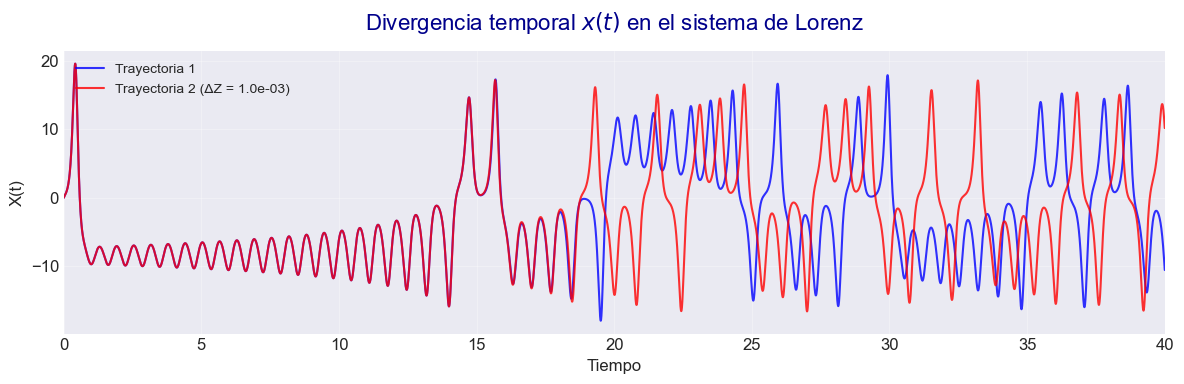

In [6]:
# ============================================================================
# 4. DIVERGENCIA TEMPORAL: EL EFECTO MARIPOSA EN X(t)
# ============================================================================

plt.figure(figsize=(12, 4))
plt.style.use('seaborn-v0_8-darkgrid')

# Graficar X(t) para ambas trayectorias en función del tiempo
plt.plot(t, trajectory_1[:, 0], label='Trayectoria 1', lw=1.5, color='blue', alpha=0.8)
plt.plot(t, trajectory_2[:, 0], 
         label=f'Trayectoria 2 (ΔZ = {initial_state_2[2] - initial_state_1[2]:.1e})', 
         lw=1.5, color='red', alpha=0.8)

plt.title('Divergencia temporal $x(t)$ en el sistema de Lorenz', fontsize=16, color='darkblue', pad=15)

# Etiquetas de ejes
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('X(t)', fontsize=12)

# Leyenda en esquina superior izquierda con fondo semitransparente
plt.legend(loc='upper left', fontsize=10, framealpha=0.9)

# Cuadrícula sutil para mejor lectura de valores
plt.grid(True, alpha=0.3)

# Ajustar límites del eje X para mostrar toda la simulación
plt.xlim([0, t[-1]])  # t[-1] es el último valor del array t (40 en este caso)

# Ajustar layout automáticamente para evitar cortes
plt.tight_layout()

# Mostrar la gráfica
plt.show()


Esta gráfica muestra la evolución temporal de la coordenada **X** (tasa de convección) para las dos trayectorias con condiciones iniciales ligeramente diferentes. Es la visualización más directa del **efecto mariposa**.

----

**Frase histórica de Lorenz (1972):**

> "Un aleteo de mariposa en Brasil puede causar un tornado en Texas."

**... y el antecedenta de Ray Bradbury (1963):**

> "*He looked at the soles of his shoes. Embedded in the mud, glistening green and gold and black, was a butterfly, very beautiful and very dead.*"


**... y Zitarrosa (1985):**
> "*... sino que era mariposa, nada más: en la ciudad, presa y ya muerta de antemano, fatalmente; buscando en ese bailar loco y frágil un ala, un grano, una pizca de polen en el cemento.*"

---

### 4. Mackey–Glass y modelado de fenómenos biológicos

El sistema de Mackey–Glass (1977) se propuso para describir procesos fisiológicos con **retroalimentación retardada**, como la producción de células sanguíneas:

$$
\frac{dx}{dt} = \frac{\beta x(t-\tau)}{1 + x(t-\tau)^n} - \gamma x(t)
$$

<ul><li><b>Parámetros típicos:</b></li>
    <ul>
    <li>$\beta = 0.2$ (tasa de producción)</li>
    <li>$\gamma = 0.1$ (tasa de decaimiento)</li>
    <li>$n = 10$ (exponente no lineal)</li>
    <li>$\tau$ = retardo temporal (**parámetro crítico**)<br>Para $\tau > 16.8$, el sistema se vuelve caótico.</li>
    </ul>
</ul>

<ul>
    <li><b>Benchmark clásico</b> en predicción de series de tiempo no lineales.</li>
</ul>

<ul><li><b>Fenómeno común:</b> Retroalimentación retardada aparece en:</li>
    <ul>
    <li>Regulación hormonal (insulina, cortisol)</li>
    <li>Dinámica poblacional (depredador-presa)</li>
    <li>Sistemas económicos (inflación, inversión)</li>
    </ul>
</ul>

<ul><li><b>Desafío técnico:</b> ARIMA, Exponential Smoothing y regresión lineal fallan completamente.</li>
</ul>


> Mackey-Glass no es solo una ecuación diferencial; es un gimnasio mental para diseñar algoritmos inteligentes que manejen complejidad temporal. Si una metaheurística puede navegar este sistema, está lista para desafíos del mundo real en finanzas, biología y más.

---

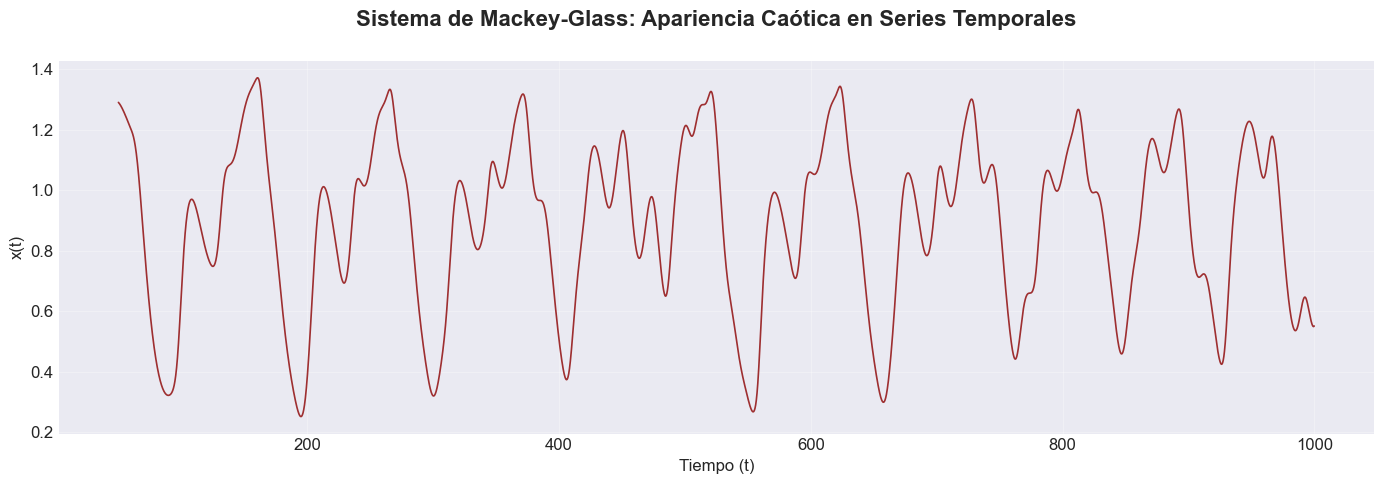

In [7]:
# ============================================================================
# SIMULACIÓN SIMPLIFICADA DE LA SERIE MACKEY-GLASS
# ============================================================================

# ----------------------------------------------------------------------------
# PARÁMETROS PARA RÉGIMEN CAÓTICO
# ----------------------------------------------------------------------------
beta = 0.2      # Tasa de producción
gamma = 0.1     # Tasa de decaimiento  
n = 10          # Exponente de saturación
tau = 30        # Retardo temporal (¡CAÓTICO cuando > 16.8!)
x0 = 0.5        # Condición inicial

# ----------------------------------------------------------------------------
# INTEGRACIÓN NUMÉRICA SIMPLIFICADA
# ----------------------------------------------------------------------------
# Tiempo de simulación (pasos discretos)
total_steps = 10000
dt = 0.1  # Paso de tiempo

# Inicializar arrays
t = np.arange(0, total_steps * dt, dt)
x = np.zeros_like(t)

# Condición inicial: x(t) = 0.5 para t ≤ 0
for i in range(len(t)):
    if i == 0:
        x[i] = x0
    else:
        # Calcular índice retardado
        tau_steps = int(tau / dt)
        
        # Manejar caso cuando no hay suficiente historia
        if i > tau_steps:
            x_tau = x[i - tau_steps]
        else:
            x_tau = x0
            
        # Ecuación de Mackey-Glass (método de Euler simple)
        dxdt = beta * x_tau / (1 + x_tau**n) - gamma * x[i-1]
        x[i] = x[i-1] + dt * dxdt

# ----------------------------------------------------------------------------
# VISUALIZACIÓN
# ----------------------------------------------------------------------------
plt.figure(figsize=(14, 5))
plt.style.use('seaborn-v0_8-darkgrid')

# Eliminar primeros 500 puntos (transitorios)
start_idx = 500
t_plot = t[start_idx:]
x_plot = x[start_idx:]

# Gráfica principal
plt.plot(t_plot, x_plot, color='darkred', linewidth=1.2, alpha=0.8)

# Configuración del gráfico
plt.title('Sistema de Mackey-Glass: Apariencia Caótica en Series Temporales', 
          fontsize=16, fontweight='bold', pad=25)

plt.xlabel('Tiempo (t)', fontsize=12)
plt.ylabel('x(t)', fontsize=12)
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


### Aplicaciones Médicas Reales

Los sistemas tipo Mackey-Glass pueden modelar sistemas como:

* La **hematopoyesis** (producción de células sanguíneas) $\rightarrow$ Leucemia: desregulación del sistema.
* La **variabilidad del ritmo cardíaco (HRV)** $\rightarrow$ HRV normal: caótico (¡sano!). HRV regular: enfermedad (pérdida de complejidad).
* La ocurrencia de crisis en **epilepsia** $\rightarrow$ Transición súbita a sincronización patológica.


## 5. Mapas caóticos

A veces una sola ecuación discreta genera complejidad extrema.

### Mapa logístico

$$x_{t+1} = r x_t (1 - x_t)$$

**Diagrama de bifurcación:**

* $r < 3$: Convergencia a punto fijo
* $3 < r < 3.57$: Ciclos periódicos (periodo 2, 4, 8...)
* $r > 3.57$: Ruta al caos (cascada de bifurcaciones)
* $r = 4$: Caos completo

---

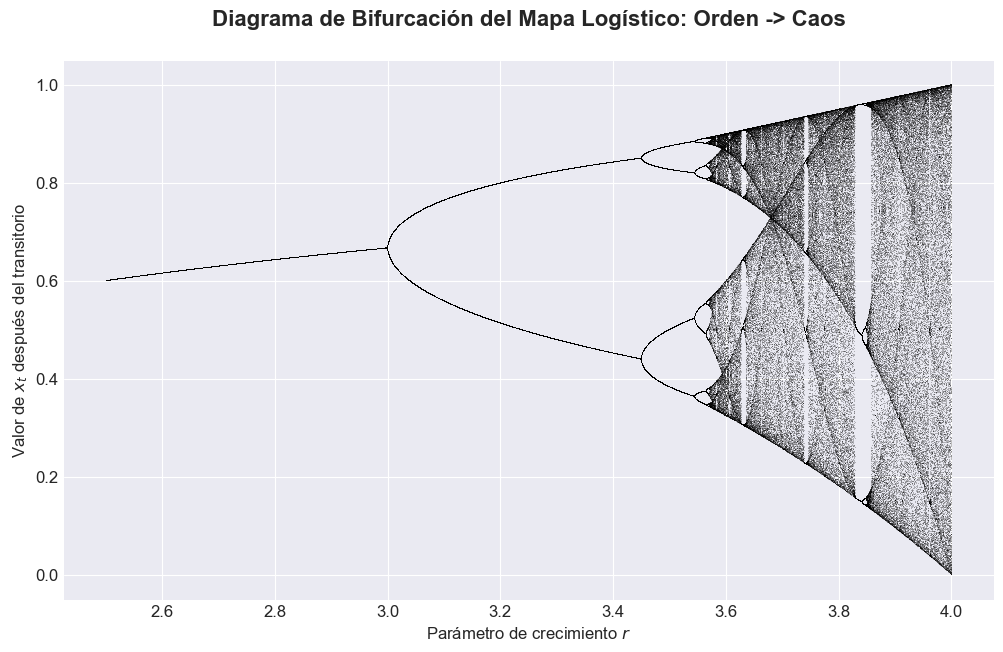

In [11]:

N = 1000 # Iteraciones a descartar (transitorio)
M = 100  # Puntos a graficar por cada r
rs = np.linspace(2.5, 4.0, 5000) # Rango de r

x = 1e-5 * np.ones(len(rs)) # Condición inicial
points = []

for i in range(N + M):
    x = rs * x * (1 - x)
    if i >= N:
        points.append(x)

points = np.array(points)

plt.figure(figsize=(12, 7))
plt.plot(rs, points.T, ',k', alpha=0.25)
plt.title("Diagrama de Bifurcación del Mapa Logístico: Orden -> Caos", fontsize=16, fontweight='bold', pad=25)
plt.xlabel("Parámetro de crecimiento $r$")
plt.ylabel("Valor de $x_t$ después del transitorio")
plt.show()



El diagrama de bifurcación revela cómo un sistema determinista transita del orden al caos. 

Para valores bajos de $r$ (izquierda), todos los puntos convergen a una única línea: el sistema tiene un equilibrio estable. Al aumentar $r$ alrededor de 3, esta línea se bifurca en dos ramas—el sistema oscila entre dos valores. Más adelante, cada rama se divide nuevamente (4, 8, 16... estados periódicos) en una cascada acelerada de bifurcaciones. Finalmente, cerca de $r \approx 3.57$, el diagrama "explota" en una banda continua de puntos negros: el sistema se vuelve caótico y visita un continuo de estados de forma aparentemente aleatoria. 

Lo notable: dentro del caos aparecen "ventanas de orden" (líneas blancas verticales), donde momentáneamente resurgen ciclos periódicos—evidencia de que orden y caos no son excluyentes, sino que coexisten en una estructura fractal. 

Esta misma estructura matemática aparece en modelos de poblaciones biológicas, tasas de interés y dinámicas neuronales.

### Mapa de Hénon: Caos en 2D

$$
\begin{aligned}
x_{t+1} &= 1 - a x_t^2 + y_t \\
y_{t+1} &= b x_t
\end{aligned}
$$

Parámetros clásicos: $a = 1.4$, $b = 0.3$

**Propiedades:**

* Atractor con **estructura fractal** (autosimilar)
* Dimensión de correlación $\approx 1.26$ (**fractal!**)

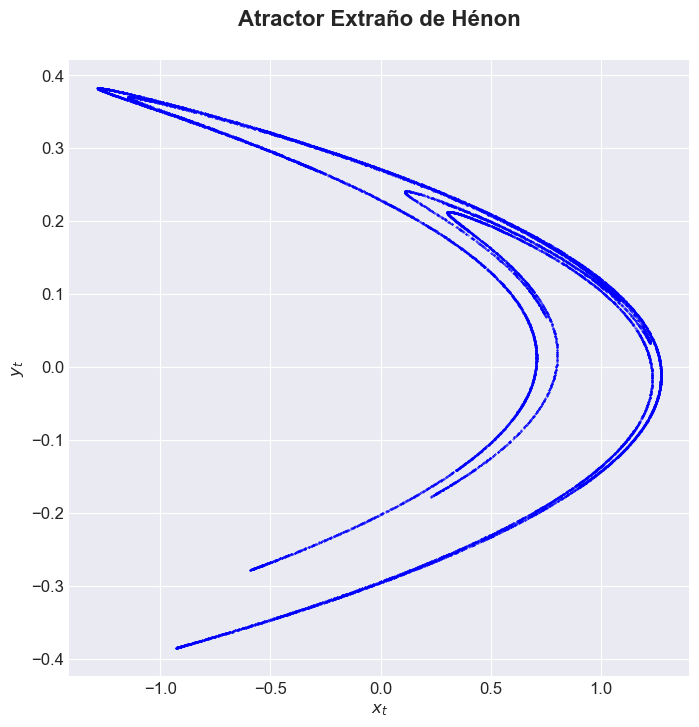

In [13]:
a = 1.4
b = 0.3
N = 20000
x = np.zeros(N)
y = np.zeros(N)

x[0], y[0] = 0.1, 0.1

for t in range(N - 1):
    x[t+1] = 1 - a * x[t]**2 + y[t]
    y[t+1] = b * x[t]

plt.figure(figsize=(8, 8))
plt.scatter(x[1000:], y[1000:], s=0.1, color='blue') # Descartar transitorio
plt.title("Atractor Extraño de Hénon", fontsize=16, fontweight='bold', pad=25)
plt.xlabel("$x_t$")
plt.ylabel("$y_t$")
plt.show()

El atractor de Hénon muestra cómo el caos puede tener estructura geométrica. A primera vista parece una curva suave, pero al acercarnos (zoom) descubriríamos que cada "línea" es en realidad un conjunto de líneas paralelas más finas, y cada una de esas se subdivide nuevamente—una estructura fractal que se repite a todas las escalas. Los 20,000 puntos graficados nunca se repiten exactamente, pero quedan confinados a esta forma de "boomerang" con pliegues. La dimensión fractal de ~1.26 significa que el atractor es "más que una línea" (dimensión 1) pero "menos que una superficie" (dimensión 2)—ocupa un espacio intermedio. 

Este tipo de atractores extraños aparecen en sistemas físicos reales: péndulos forzados, osciladores electrónicos, reacciones químicas oscilantes. El mapa de Hénon fue fundamental históricamente porque demostró que el caos no requiere ecuaciones diferenciales complicadas—dos ecuaciones algebraicas simples bastan para generar complejidad infinita.

### Mapa de Ikeda: Óptica cuántica caótica

$$
\begin{aligned}
x_{t+1} &= 1 + u(x_t \cos \theta_t - y_t \sin \theta_t) \\
y_{t+1} &= u(x_t \sin \theta_t + y_t \cos \theta_t) \\
\theta_t &= 0.4 - \frac{6}{1 + x_t^2 + y_t^2}
\end{aligned}
$$

Origen: Simula la luz dentro de una cavidad óptica con retroalimentación no lineal.

---

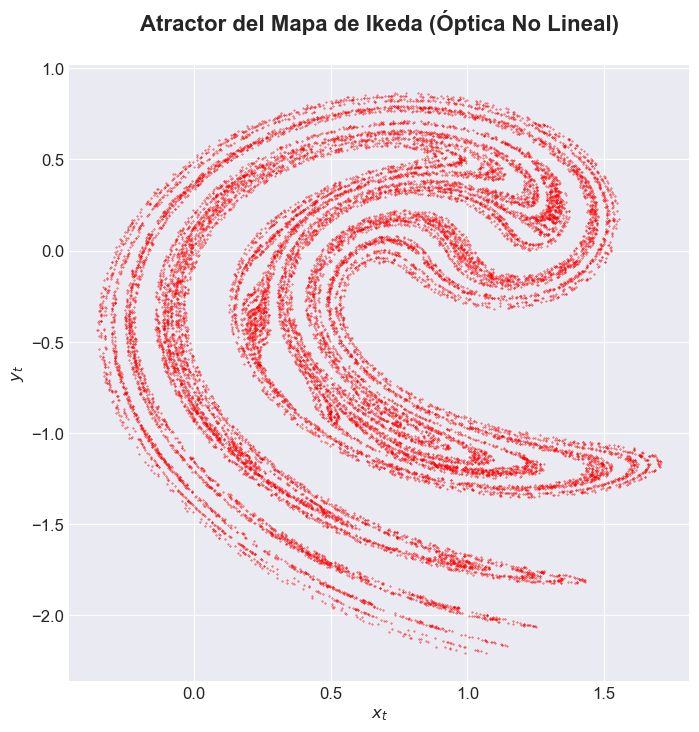

In [15]:
u = 0.9
N = 20000
x = np.zeros(N)
y = np.zeros(N)

x[0], y[0] = 0.1, 0.1

for t in range(N - 1):
    denom = 1 + x[t]**2 + y[t]**2
    theta_t = 0.4 - 6 / denom
    x[t+1] = 1 + u * (x[t] * np.cos(theta_t) - y[t] * np.sin(theta_t))
    y[t+1] = u * (x[t] * np.sin(theta_t) + y[t] * np.cos(theta_t))

plt.figure(figsize=(8, 8))
plt.scatter(x[1000:], y[1000:], s=0.1, color='red')
plt.title("Atractor del Mapa de Ikeda (Óptica No Lineal)", fontsize=16, fontweight='bold', pad=25)
plt.xlabel("$x_t$")
plt.ylabel("$y_t$")
plt.show()

#### 5.4 El Desafío para Machine Learning

Lo sorprendente de estos mapas:

A pesar de ser ecuaciones deterministas:

* Sus series parecen estocásticas
* Tienen autocorrelaciones complejas
* Presentan atractores fractales
*  No se ajustan a ARIMA (no son lineales)
* Rompen supuesto gaussiano (colas pesadas, multimodalidad)
* Contienen ruido estructural (no es ruido de medición)

| Propiedad | Ruido Blanco | Sistema Caótico |
| :--- | :--- | :--- |
| Autocorrelación | Cero (lag > 0) | Decae rápido pero existe |
| Espectro de potencia | Plano | Estructura (no plano) |
| Dimensión de correlación | Infinita | Finita (fractal) |
| Predictibilidad | Cero | Corto plazo sí, largo no |
| Generación | Proceso aleatorio | Ecuación determinista |
| Sensibilidad inicial | No | Sí (exponencial) |

**Implicación:** Si un test dice "esto es ruido", no significa que lo sea. Puede ser caos determinista. Necesitas herramientas no lineales para distinguirlos.

---

## SISTEMAS REALES COMPLEJOS

### 6. Por Qué Fallan los Métodos Tradicionales

Los métodos tradicionales no fallan por incompetencia, sino porque fueron diseñados para otro mundo.

#### 6.1 Los Supuestos Implícitos del ML Clásico

| Supuesto | Realidad en Sistemas Complejos |
| :--- | :--- |
| **Linealidad** | Interacciones no lineales dominantes |
| **Gaussianidad** | Colas pesadas, multimodalidad |
| **Estacionariedad** | Cambios de régimen, no estacionariedad estructural |
| **Baja sensibilidad** | Sensibilidad exponencial a inicialización (caos) |
| **Ruido aditivo** | Ruido multiplicativo, endógeno |

---

In [ ]:
# [CÓDIGO 8: Ruido vs. Caos - ¿Cómo distinguirlos?]

print("### Dimensión de Correlación (D2) para distinguir Ruido de Caos Determinista ###")

# 1. Generar series (reutilizando las de Lorenz y Ruido)
N_points = 5000
lorenz_series = odeint(lorenz_system, [1.0, 1.0, 1.0], np.arange(0, N_points * 0.01, 0.01), args=(10, 28, 8/3))[1000:, 0]
white_noise = np.random.normal(size=len(lorenz_series))

print("Series Generadas (Lorenz: determinista; Ruido: estocástico)")

# 2. Reconstrucción de espacio de fase (Takens' embedding - visual)
def plot_takens(series, lag, dim, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(series[:-lag], series[lag:], s=1, alpha=0.5)
    plt.title(title)
    plt.xlabel("$x_t$")
    plt.ylabel("$x_{t+\tau}$")
    plt.show()

plot_takens(lorenz_series, lag=10, dim=2, title="Embedding 2D - Serie de Lorenz (Estructura)")
plot_takens(white_noise, lag=1, dim=2, title="Embedding 2D - Ruido Blanco (Nube difusa)")

# 3. Cálculo de Dimensión de Correlación (D2)
try:
    D2_lorenz = nolds.corr_dim(lorenz_series, emb_dim=5, rvals=np.logspace(-2, 0, 15))
    D2_noise = nolds.corr_dim(white_noise, emb_dim=5, rvals=np.logspace(-2, 0, 15))
    
    print(f"\nDimensión de Correlación D2 (Lorenz): {D2_lorenz:.3f} (Debe ser finita, $\approx 2.05$ $\rightarrow$ CAOS)")
    print(f"Dimensión de Correlación D2 (Ruido): {D2_noise:.3f} (Debe ser cercana a la Dim. de Embedding $\rightarrow$ Ruido)")
    
    print("\nConclusión: Solo D2 (una herramienta no lineal) revela que Lorenz es determinista de baja dimensión.")

except ImportError:
    print("Error: La librería 'nolds' no está instalada. Ejecute: !pip install nolds")

In [ ]:
# [CÓDIGO 9: Fracaso de Métodos Clásicos]

print("### Prueba de Fracaso: Predicción de Mackey-Glass con ARIMA y ETS ###")

# 1. Dataset: Serie de Mackey-Glass caótica (tau=30)
tau, n, beta, gamma = 30, 10, 0.2, 0.1
mg_series = mackey_glass(tau, n, beta, gamma, time_points=4000)[1000:3000] # 2000 puntos para estabilidad

train_size = 1800
test_size = 200
train, test = mg_series[:train_size], mg_series[train_size:]

# 2. Entrenar y predecir con ARIMA (ej. ARIMA(5,1,0))
try:
    model_arima = ARIMA(train, order=(5, 1, 0)).fit()
    pred_arima = model_arima.predict(start=train_size, end=train_size + test_size - 1)
    rmse_arima = np.sqrt(np.mean((pred_arima - test)**2))
except Exception as e:
    print(f"ARIMA falló: {e}")
    pred_arima = np.zeros(test_size)
    rmse_arima = np.nan

# 3. Entrenar y predecir con Exponential Smoothing (ETS)
try:
    model_ets = ExponentialSmoothing(train, seasonal='add', seasonal_periods=50, initialization_method='estimated').fit()
    pred_ets = model_ets.predict(start=train_size, end=train_size + test_size - 1)
    rmse_ets = np.sqrt(np.mean((pred_ets - test)**2))
except Exception as e:
    print(f"ETS falló: {e}")
    pred_ets = np.zeros(test_size)
    rmse_ets = np.nan

# 4. Visualización del Fracaso
plt.figure(figsize=(14, 6))
plt.plot(np.arange(train_size), train, label='Datos de Entrenamiento', color='blue')
plt.plot(np.arange(train_size, train_size + test_size), test, label='Realidad (Test)', color='red', linewidth=2)
plt.plot(np.arange(train_size, train_size + test_size), pred_arima, label=f'Predicción ARIMA (RMSE: {rmse_arima:.3f})', linestyle='--', color='orange')
plt.plot(np.arange(train_size, train_size + test_size), pred_ets, label=f'Predicción ETS (RMSE: {rmse_ets:.3f})', linestyle=':', color='green')
plt.title("Fracaso de Métodos Lineales/Estacionarios en Serie Caótica (Mackey-Glass)")
plt.xlabel("Paso de Tiempo")
plt.ylabel("X(t)")
plt.legend()
plt.show()

print("\nConclusión visual: Las predicciones colapsan rápidamente a un punto fijo o patrón simple, incapaces de seguir la dinámica caótica.")

### 7. Finanzas: Series Acopladas y Memoria Larga

Los mercados financieros no son ruido blanco (aunque académicos financieros durante décadas lo asumieron).

#### 7.1 Hechos Estilizados de Series Financieras

* **Heteroscedasticidad:** Varianza no constante (**Clusters de volatilidad**)
* **Colas pesadas:** Crashes más frecuentes que distribución normal predice.
* **Asimetría:** Caídas más abruptas que subidas (*leverage effect*)
* **No estacionariedad estructural:** Cambios de régimen (*bull/bear markets*)
* **Correlaciones de orden superior:** $E[r_t] \approx 0$, pero $E[|r_t|]$ tiene estructura (memoria larga en volatilidad).

#### 7.2 El Mito de la Eficiencia del Mercado

**Hipótesis de Mercado Eficiente (EMH):** "Los precios reflejan toda la información disponible, por lo que son impredecibles (*random walk*)."

**Realidad:** Los mercados son **sistemas adaptativos complejos**, no sistemas en equilibrio. Esto explica burbujas, crashes y la existencia de arbitraje estadístico exitoso (*quant funds*).

---

In [ ]:
# [CÓDIGO 10: Análisis de Serie Financiera Real]

print("Análisis de Retornos Diarios (S&P 500)")

# 1. Descargar datos (usando yfinance como ejemplo)
try:
    data = yf.download('^GSPC', start='2000-01-01', end='2024-01-01', auto_adjust=False)
    returns = data['Adj Close'].pct_change().dropna()

    # 2. Clusters de volatilidad (visualización)
    plt.figure(figsize=(14, 4))
    plt.plot(returns, lw=0.5)
    plt.title("Retornos Diarios S&P 500: Clusters de Volatilidad (Heteroscedasticidad)")
    plt.show()
    
    # 3. Test de Normalidad y Colas Pesadas (Q-Q Plot)
    plt.figure(figsize=(7, 7))
    stats.probplot(returns, dist="norm", plot=plt)
    plt.title("Q-Q Plot: Retornos vs. Distribución Normal (Colas Pesadas)")
    plt.show()
    
    # 4. Autocorrelación de |returns| (Memoria en Volatilidad)
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(np.abs(returns), lags=50, title="ACF de |Retornos| (Evidencia de Memoria Larga)")
    plt.show()
    
    # 5. Test ADF para estacionariedad de los retornos (deben ser estacionarios)
    adf_result = adfuller(returns)
    print(f"\nTest ADF (Retornos): p-value = {adf_result[1]:.4f}")
    print("Si p-value < 0.05, los retornos son estacionarios. La complejidad reside en la varianza.")

except Exception as e:
    print(f"Error al descargar/procesar datos financieros (requiere 'pip install yfinance'): {e}")

### 8. Energía Eléctrica: Ciclos, Tendencias y Respuesta Colectiva

Los sistemas eléctricos muestran complejidad organizada:

#### 8.1 Características de Series de Demanda Eléctrica

* **Multiscale:** Ciclo diario, semanal, anual.
* **No linealidad:** Efectos de saturación, respuesta no lineal a la temperatura.
* **Acoplamiento social:** Consumo humano altamente sincronizado (todos cocinan a las 7 PM).
* **Eventos extremos:** Olas de calor $\rightarrow$ picos de demanda; fallas en cascada (*blackouts*).

#### 8.2 Desafío de Predicción

Se necesita un modelo robusto que maneje múltiples estacionalidades superpuestas, no linealidad (temperatura), y la capacidad de predecir a múltiples horizontes.

---

In [ ]:
# [CÓDIGO 11: Serie de Demanda Eléctrica - Descomposición STL]

print("### Descomposición Multi-Escala de una Serie de Demanda Eléctrica (Simulada) ###")

# 1. Generar datos simulados con múltiples estacionalidades y no linealidad
time = np.arange(0, 365 * 24) / 24.0 # 2 años de datos horarios
trend = 0.5 * time + 50
daily_cycle = 20 * np.sin(2 * np.pi * time) + 10 * np.sin(4 * np.pi * time) # Dos picos diarios
annual_cycle = 40 * np.sin(2 * np.pi * time / 365.0) # Estacionalidad anual (verano/invierno)
noise = np.random.normal(0, 5, len(time))
demand = trend + daily_cycle + annual_cycle + noise
demand_series = pd.Series(demand, index=pd.to_datetime('2023-01-01') + pd.to_timedelta(np.arange(len(time)), unit='h'))

# 2. Descomposición STL
print("Realizando Descomposición STL...")
# La demanda eléctrica tiene estacionalidad diaria (24) y semanal (24*7=168)
stl_result = STL(demand_series, period=168, robust=True).fit()

# 3. Visualización
plt.figure(figsize=(10, 8))
stl_result.plot()
plt.suptitle("Descomposición STL de Demanda Eléctrica (Tendencia, Estacionalidad, Residuo)", y=1.02)
plt.show()

print("\nObservación: El residuo (remnant) aún contiene estructura no lineal no capturada por el modelo lineal de tendencia y estacionalidad.")

### 9. Neurología: EEG y Epilepsia como Sistemas Dinámicos

Las señales electroencefalográficas (EEG) son el ejemplo paradigmático de complejidad biológica.

#### 9.1 Propiedades del EEG

* **No estacionario extremo:** Transiciones abruptas (microsueños, estados mentales).
* **Sincronización patológica:** Actividad normal es **caótica** (saludable). Epilepsia es **hipersincronización súbita** (pérdida de complejidad).
* **Multi-canal:** Acoplamiento espacial (redes funcionales).

#### 9.2 Detección de Epilepsia como Problema de Clasificación

El desafío es predecir una convulsión (*pre-ictal*) antes de que ocurra, utilizando *features no lineales* críticos (entropía, dimensión de correlación) que distinguen el caos saludable del orden patológico.

### Detección de Transición (Pre-Ictal $\rightarrow$ Ictal) mediante Entropía de Muestra


In [ ]:
# [CÓDIGO 12: Análisis de EEG Epiléptico (Simulado) - Entropía]


# 1. Simulación de señal EEG (Transición: Caos $\rightarrow$ Orden)
N = 3000
noise_normal = np.random.randn(N) * 0.5 + np.sin(np.arange(N) * 0.1) # Actividad 'caótica' normal
spike_onset = 2000
ictal_burst = np.sin(np.arange(N - spike_onset) * 0.5) * 5 # Sincronización patológica (orden)
eeg_signal = np.concatenate([noise_normal[:spike_onset], ictal_burst + noise_normal[spike_onset:] * 0.1])

# 2. Visualización de la señal cruda
plt.figure(figsize=(14, 4))
plt.plot(eeg_signal, lw=0.5)
plt.axvline(x=spike_onset, color='red', linestyle='--', label='Inicio Ictal')
plt.title("Señal EEG Simulada: Transición Caótica -> Ordenada (Epilepsia)")
plt.show()

# 3. Entropía de Muestra (Sample Entropy - SampEn) por ventana
window_size = 250
step = 50
sampen_values = []
for i in range(0, len(eeg_signal) - window_size, step):
    window = eeg_signal[i:i + window_size]
    try:
        # El valor de SampEn BAJA cuando la complejidad (caos) se pierde
        sampen = nolds.sampen(window, emb_dim=2, tolerance=0.2 * np.std(window))
        sampen_values.append(sampen)
    except:
        sampen_values.append(np.nan)

plt.figure(figsize=(14, 4))
plt.plot(np.arange(len(sampen_values)) * step + window_size / 2, sampen_values, 'o-', color='blue')
plt.axvline(x=spike_onset, color='red', linestyle='--', label='Inicio Ictal')
plt.title("Entropía de Muestra (SampEn): Pérdida de Complejidad en la Transición")
plt.xlabel("Tiempo")
plt.ylabel("SampEn (Complejidad)")
plt.show()

print("\nObservación: La caída en SampEn indica que la señal se ha vuelto más regular/sincronizada, lo que es un indicador de patología en este contexto.")

### 10. Señales Fisiológicas: Corazón, Respiración, Movimiento

El corazón humano es un oscilador caótico (sí, ¡el caos es saludable!).

#### 10.1 Variabilidad del Ritmo Cardíaco (HRV)

| Condición | HRV | Interpretación |
| :--- | :--- | :--- |
| Persona sana | Alta variabilidad | Sistema adaptativo, **caótico** |
| Enfermedad cardíaca | Baja variabilidad | **Pérdida de complejidad** |
| Antes de infarto | HRV disminuye | Señal de alarma |

**Análisis no lineal de HRV:** Gráfico de Poincaré, Entropía aproximada (ApEn), Entropía de muestra (SampEn), Dimensión de correlación.

---

In [ ]:
# [CÓDIGO 13: Análisis de HRV - Gráfico de Poincaré]

print("### Gráfico de Poincaré para Variabilidad del Ritmo Cardíaco (HRV) ###")

# 1. Simulación de RR intervals (tiempo entre latidos)
# HRV Sano (Caótico): Media estable con alta varianza (elipse difusa)
rr_sano = np.random.normal(loc=1000, scale=10, size=500) + 10 * np.sin(np.arange(500) * 0.1)
# HRV Enfermo (Regular): Media estable con baja varianza (punto/línea compacta)
rr_enfermo = np.random.normal(loc=1000, scale=2, size=500)

# 2. Gráfico de Poincaré (RR_n vs. RR_{n+1})
def plot_poincare(rr_intervals, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(rr_intervals[:-1], rr_intervals[1:], s=5, alpha=0.6)
    plt.axline((1000, 1000), slope=1, color='red', linestyle='--')
    plt.title(title)
    plt.xlabel("$RR_n$ (ms)")
    plt.ylabel("$RR_{n+1}$ (ms)")
    plt.axis('equal')
    plt.grid(True)
    plt.show()

plot_poincare(rr_sano, "HRV Sano (Alta Complejidad - Elipse Ancha)")
plot_poincare(rr_enfermo, "HRV Enfermo (Baja Complejidad - Punto Compacto)")

print("\nConclusión: Una elipse ancha (mayor área) en el Gráfico de Poincaré indica un sistema más complejo/caótico, lo cual es un signo de salud en el corazón.")

## PARTE 3: SÍNTESIS Y CONCLUSIONES

### 11. Anatomía de un Fracaso: Por Qué Fallan los Modelos Tradicionales

Los métodos tradicionales asumen un mundo dócil:

| Supuesto | Mundo Dócil (Asumido) | Mundo Real (Observado) |
| :--- | :--- | :--- |
| **Linealidad** | $y = mx + b$ | $y = f(x_1, \dots, x_n)$ con $f$ no lineal |
| **Ruido** | Aditivo gaussiano | Multiplicativo, endógeno, estructural |
| **Estacionariedad** | Media y varianza constantes | Cambios de régimen, tendencias |
| **Sensibilidad** | Pequeños errores $\rightarrow$ pequeños efectos | Sensibilidad exponencial (caos) |
| **Mínimos** | Un solo óptimo global | Múltiples mínimos locales |

---

In [ ]:
# [CÓDIGO 14: Mundo Dócil vs. Mundo Real - El Contraste Visual]

print("### El Contraste Visual: Modelado Lineal vs. Realidad No Lineal ###")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Mundo Dócil vs. Mundo Real', fontsize=16)

# Panel 1: Función lineal con ruido gaussiano
X1 = np.linspace(0, 10, 100).reshape(-1, 1)
y1 = 2 * X1 + 5 + np.random.normal(0, 1, 100).reshape(-1, 1)
lr1 = LinearRegression().fit(X1, y1)
axes[0, 0].scatter(X1, y1, s=10)
axes[0, 0].plot(X1, lr1.predict(X1), color='red')
axes[0, 0].set_title("1. Mundo Dócil: Linealidad Funciona")

# Panel 2: Función no lineal (sin²(x)) con ruido
X2 = np.linspace(0, 10, 100).reshape(-1, 1)
y2 = 5 * np.sin(X2)**2 + np.random.normal(0, 0.5, 100).reshape(-1, 1)
lr2 = LinearRegression().fit(X2, y2)
axes[0, 1].scatter(X2, y2, s=10)
axes[0, 1].plot(X2, lr2.predict(X2), color='red')
axes[0, 1].set_title("2. Mundo Real: No Linealidad (Regresión Lineal Falla)")

# Panel 3: Serie de Lorenz (caótica) y su predicción 'lineal' (ARIMA)
lorenz_series = odeint(lorenz_system, [1.0, 1.0, 1.0], np.arange(0, 30, 0.01), args=(10, 28, 8/3))[1000:, 0]
train_l = lorenz_series[:1500]
test_l = lorenz_series[1500:2000]
try:
    model_arima_l = ARIMA(train_l, order=(2, 0, 0)).fit()
    pred_arima_l = model_arima_l.predict(start=1500, end=2000-1)
except Exception:
    pred_arima_l = np.ones(len(test_l)) * np.mean(train_l)

axes[1, 0].plot(np.arange(len(lorenz_series[:2000])), lorenz_series[:2000], lw=0.5, color='blue', label='Real')
axes[1, 0].plot(np.arange(1500, 2000), pred_arima_l, color='red', linestyle='--', label='Pred. ARIMA')
axes[1, 0].axvline(x=1500, color='grey', linestyle=':')
axes[1, 0].set_title("3. Mundo Real: Caos Determinista (ARIMA Colapsa)")

# Panel 4: Serie Financiera Real (S&P 500) - Colas pesadas
returns_sample = np.concatenate([np.random.normal(0, 1, 100), np.random.normal(0, 5, 20)]) # Normal + 20 outliers
axes[1, 1].hist(returns_sample, bins=30, density=True, alpha=0.7, label='Empírica')
xmin, xmax = axes[1, 1].get_xlim()
x_norm = np.linspace(xmin, xmax, 100)
p_norm = stats.norm.pdf(x_norm, np.mean(returns_sample), np.std(returns_sample))
axes[1, 1].plot(x_norm, p_norm, 'r--', label='Gaussiana (Asumida)')
axes[1, 1].set_title("4. Mundo Real: Colas Pesadas (No Gaussianidad)")
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 12. La Necesidad de Metaheurísticas: Un Argumento Estructural

Esta libreta es un argumento estructural para justificar el curso completo:

#### 12.1 Si el Mundo es Complejo, Necesitamos Herramientas Complejas

**Silogismo:**

1.  **Premisa 1:** Los datos reales provienen de sistemas complejos.
2.  **Premisa 2:** Los sistemas complejos violan supuestos de métodos clásicos.
3.  **Premisa 3:** Los métodos clásicos fallan cuando sus supuestos se violan.
4.  **Conclusión:** Necesitamos métodos que no asuman linealidad, convexidad ni estacionariedad.

**Metaheurísticas cumplen esto porque:**

* No requieren gradientes (funcionan en espacios discretos y rugosos)
* Exploran globalmente (resisten mínimos locales)
* Son flexibles (se adaptan a cualquier función objetivo no lineal)
* Manejan multimodalidad (poblaciones diversas)

#### 12.2 Tabla Comparativa Final

| Método | Supuestos Clave | Funciona en Sistemas Complejos |
| :--- | :--- | :--- |
| Regresión Lineal | Linealidad, Gaussianidad | No |
| ARIMA | Estacionariedad, Linealidad | No |
| Gradient Descent | Diferenciabilidad, Convexidad | No |
| Redes Neuronales | Datos abundantes, suavidad | Parcial (sobreajuste, caja negra) |
| **Metaheurísticas** | **Ninguno (evaluación de función)** | **Sí** |


---

### Problemas de optimización en series de tiempo complejas

Modelar, predecir y analizar series de tiempo complejas requiere resolver problemas de optimización donde las metaheurísticas destacan:

**1. Reconstrucción de espacios de fase**  
Dado $\{x_t\}$, encontrar la dimensión de embedding $d$ y el retardo $\tau$ que mejor reconstruyen el atractor subyacente:

$$(\hat{d}, \hat{\tau}) = \arg\min_{d,\tau} E[\text{FNN}(d,\tau)] + \lambda \cdot \text{Complejidad}(d)$$

donde FNN (False Nearest Neighbors) mide qué tan bien se preserva la geometría del sistema. Este es un problema de **optimización discreta multiobjetivo** sin gradientes.

**2. Identificación de parámetros en modelos caóticos**  
Si sospechamos que los datos provienen de un sistema tipo Lorenz, debemos estimar $\sigma, \rho, \beta$ minimizando:

$$\hat{\theta} = \arg\min_{\theta} \sum_{t=1}^T \|x_t - \text{simulate}(\theta, x_0, t)\|^2$$

El espacio de parámetros tiene **múltiples cuencas de atracción** (distintos regímenes dinámicos) y la función objetivo es **no diferenciable** (pequeños cambios en $\theta$ pueden causar bifurcaciones).

**3. Selección de arquitecturas de predictores**  
Diseñar un predictor para una serie caótica implica optimizar simultáneamente:
- Qué retardos incluir: $\{x_{t-1}, x_{t-5}, x_{t-12}, ...\}$
- Qué transformaciones aplicar: $\{x_t, x_t^2, \sin(x_t), ...\}$
- Qué topología de red usar: número de capas, unidades, conexiones recurrentes

El espacio de búsqueda es **combinatorio × continuo × estructural**, con evaluación costosa (entrenar y validar cada candidato).

**4. Segmentación de regímenes dinámicos**  
Particionar la serie en intervalos donde la dinámica es cualitativamente distinta:

$$\hat{S} = \arg\min_{S} \sum_{i=1}^k \text{Entropía}(S_i) + \alpha \cdot |S|$$

donde $S = \{S_1, ..., S_k\}$ son segmentos. Esto es **clustering temporal con penalización de complejidad**, sin estructura convexa.

### El rol de las metaheurísticas

En todos estos casos:
- **No hay gradiente analítico** (o es intratable de calcular)
- **La función objetivo es costosa** (requiere simular trayectorias, entrenar modelos)
- **El espacio es multimodal** (muchas configuraciones localmente buenas)
- **Hay restricciones complejas** (estabilidad numérica, plausibilidad física)

Las metaheurísticas (algoritmos genéticos, PSO, evolución diferencial, simulated annealing) están diseñadas precisamente para navegar estos paisajes de optimización:
- **Exploración global** para escapar de óptimos locales
- **Sin requerimiento de diferenciabilidad**
- **Paralelización natural** (evaluar poblaciones de soluciones)
- **Incorporación flexible de conocimiento del dominio** (operadores especializados, restricciones)

### Sistemas caóticos como laboratorio controlado

Los sistemas de Lorenz y Mackey-Glass que estudiaremos son **bancos de prueba ideales**:
- Conocemos la verdad fundamental (las ecuaciones exactas)
- Generamos datos sintéticos a voluntad (sin costo de recolección)
- Modulamos la complejidad mediante parámetros
- **Verificamos si recuperamos la estructura subyacente**

Si una metaheurística no puede calibrar correctamente los parámetros de Lorenz—donde conocemos la respuesta—difícilmente confiamos en ella para series reales de mercados financieros o clima, donde la verdad es inaccesible.

Este es el puente entre teoría de sistemas complejos y aplicación práctica: **dominar la optimización en caos sintético para enfrentar la complejidad de datos reales**.

<div style="border: 2px solid #24398A; border-radius: 15px; padding: 20px; background-color: #fcfcfc;">
    <h3 style="color: #24398A; margin-top: 0;">Conclusiones: Dinámicas No Lineales y Emergencia</h3>
    <p style="font-size: 15px; line-height: 1.6;">
        Hemos abordado la complejidad no como una medida de dificultad, sino como una propiedad intrínseca de los sistemas donde el todo es mayor que la suma de sus partes. Este enfoque es crucial para modelar fenómenos económicos, sociales y biológicos con fidelidad.
    </p>
    <ul style="font-size: 14px; color: #333;">
        <li><b>Criterio de Modelado:</b> El reconocimiento de la auto-organización y la sensibilidad a condiciones iniciales permite anticipar comportamientos que los modelos lineales ignoran.</li>
        <li><b>Fundamentación Técnica:</b> Las metaheurísticas se justifican formalmente como las herramientas idóneas para navegar la rugosidad de estos sistemas.</li>
    </ul>

</div>